# Do symbol hints help model agreement checks? — Candidate-Signature Consensus (CSC)

This notebook is a runnable demo of the **iteration-4 T6-P experiment**. The experiment asks whether peer-consensus
checks of NL→FOL translations get better when the peer models are **cued with a symbol list**.

**What CSC measures.** Take a sentence and a candidate FOL translation. Several peer models from *other* families
(deepseek-v3.2, phi-4, gpt-4.1-mini; qwen3-235b as the 4th peer) translate the same sentence. Each peer is shown the
candidate's own symbol list (name/arity). A peer **agrees** when its formula is *exactly* z3-equivalent to the
candidate, after lower-casing the names and with no aligner.

`c = 1 − agree / used`. **Higher means more likely an error**, and a row is flagged when `c > 0.5`.

**What actually ran (deviation D-BUDGET).** The OpenRouter budget ran out before any CSC peer call, so the CSC peers
proper were never generated. Gates G3-P, G4 and MT are **UNTESTED**, not failed. The artifact scored every $0 arm:
* **SIGPROXY** — signature-cued outputs of the same four families. They come from exp 7's SIG condition, which cued the
  closed *template* signature.
* **FREE3** — the same three families *uncued*. This is the matched-resource baseline, scored with exact, align and
  lower-case exact agreement.
* **Typed repair** — a same-vocabulary search that recovers the **error type** (NEG, QUANT, SWAP, DROP, …).

**What this notebook runs.** `method.py` is a thin orchestrator that runs the stage scripts with `subprocess`. The
notebook keeps its code unchanged and then runs the CPU core of the two stages behind the headline numbers:
* **STAGE 6 `score`** — `score_task` from `src/csc_score.py`, which computes the SIGPROXY and FREE3 scores;
* **STAGE 7 `typing`** — `job` from `src/csc_typing.py`, the typed-repair search;

followed by a small slice of the **`analysis`** stage. The inputs are a curated subset of the **PERTURB_RCOMP_CSC**
dataset: long R_COMP sentences, each with its correct BASE formula, synthetic mutants with known error types, and
meaning-preserving controls.

The scoring library (`csc_lib.py` plus 6 vendored modules) ships **verbatim** inside `mini_demo_data.json`, and the
notebook writes it to disk. No API calls are made; all peer formulas are pre-recorded.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver, loguru — NOT pre-installed on Colab, always install
_pip('z3-solver==5.1.0.0', 'loguru==0.7.3')

# numpy, scipy, pandas, matplotlib — pre-installed on Colab, install locally only (at Colab's versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'pandas==2.2.2', 'matplotlib==3.10.0')

In [2]:
# --- original method.py imports (unchanged) ---
from __future__ import annotations

import argparse
import asyncio
import subprocess
import sys
from pathlib import Path

from loguru import logger

# --- extra imports used by the scoring / typing / analysis cells (from src/csc_score.py, src/csc_typing.py) ---
import json
import os
import signal
import time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_An1uy2kF2SjZ/round-4/experiment-10/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print(f"dataset={data['dataset']}  rows={data['n_rows']}  bases={data['n_bases']}")
print("bundled source files:", list(data["source_files"]))
print(pd.Series(Counter(r["op_label"] for r in data["rows"])).rename("rows per operator/control").to_string())

Curated subset of PERTURB_RCOMP_CSC (iteration-4 CSC experiment): R_COMP bases with their perturbation mutants and meaning-preserving controls; scoring tasks exactly as src/csc_score.py builds them.
dataset=PERTURB_RCOMP_CSC  rows=100  bases=7
bundled source files: ['csc_lib.py', 'vendor_x8/consensus_lib.py', 'vendor_x8/pairs.py', 'vendor_x8/peer_text.py', 'vendor_x8/vendor_c/common.py', 'vendor_x8/vendor_c/repair_census.py', 'vendor_x8/vendor_e/fol.py']
BASE               7
ADD_FOREIGN        7
ADD_INTERNAL       6
BIND               7
CONN               7
CONTRAPOSITIVE     7
DROP               7
MEANING_RENAME     7
NEG                7
QUANT              7
RENAME_SYN         4
REORDER_COMMUTE    7
RESTR              6
REV                6
SWAP               5
RENAME_NONCE       3


## Config

These are the tunable parameters. The first three are the original values from `src/csc_score.py` and
`src/csc_typing.py`. `N_ROWS` sets how many demo rows are scored; the full run scores all **1,946 PERTURB_RCOMP_CSC
rows** (and 5,402 PERTURB rows in total), using a process pool.

In [5]:
N_ROWS = 100          # rows of mini_demo_data.json to score (demo max 100; original full run: 1,946 R_COMP rows / 5,402 PERTURB rows)
GRADED_CAP_S = 90     # per-row wall-clock cap on the graded consensus (original csc_score.py value)
BUDGET_S = 6.0        # typed-repair search budget per (mutant, target) in seconds (original csc_typing.py value)
FLAG_AT = 0.5         # a row is flagged as an error when c > FLAG_AT (pre-registered threshold)

## Materialise the scoring library

The pipeline expects the layout `<ROOT>/src/csc_lib.py` and `<ROOT>/src/vendor_x8/...`. `csc_lib` locates the
vendored exp-8 parser, the z3 equivalence code and `repair_census` relative to its own file, so the bundled sources are
written into that layout under `./csc_src/`. They are byte-identical to the artifact's files.

In [6]:
ROOT = Path("csc_src").resolve()      # stands in for the artifact directory (method.py: ROOT = Path(__file__).resolve().parent)
for rel, txt in data["source_files"].items():
    p = ROOT / "src" / rel
    p.parent.mkdir(parents=True, exist_ok=True)
    p.write_text(txt)
SRC = ROOT / "src"
print("wrote", len(data["source_files"]), "files under", SRC)

wrote 7 files under csc_src/src


## `method.py` — the stage orchestrator (original code)

The artifact's `method.py` runs the pipeline stages below. Each one is a separate script that it calls through
`subprocess`. The API stages `pilot` and `peers` run only when a 1-token probe shows that the OpenRouter key still has
budget. In this run it had none (**D-BUDGET**), so they were skipped.

The code is unchanged apart from where `ROOT` comes from: it is set in the cell above, not from `__file__`. The
notebook does **not** call `main()`. It needs the full repository (views, prompts, API client) and argparse. Instead,
the next cells run the CPU core of the `score` and `typing` stages directly on the demo rows.

In [7]:
"""Orchestrator: Candidate-Signature Consensus (CSC) on PERTURB and R_COMP (iteration 4, T6-P).

Stages (comma-separated with --stage, or 'all'):
  views     STAGE 1  data views, signatures, sig_sharing.csv, firewalled FREE view, FREE3 peers      (CPU, $0)
  tests     unit tests (tests/test_csc_lib.py) - must pass before any API call                      (CPU, $0)
  pilot     STAGE 3  30 signatures x 4 models; compliance, usage, projection, prompt choice          (API ~$0.12)
  prereg    STAGE 4  freeze results/prereg_csc_P.json (+sha256); never overwritten                  (CPU)
  peers     STAGE 5  CSC peer sweeps perturb_E -> free -> perturb_R -> sig -> retest                 (API ~$3.4)
  local     LOCAL2 secondary local-peer arm (llama.cpp, CPU)                                          ($0)
  score     STAGE 6  CSC / SIGPROXY / FREE3 scores (+ --local LOCAL2 scores)                         (CPU)
  typing    STAGE 7  same-vocabulary typed-repair searches                                          (CPU)
  analysis  STAGE 7  all tables (verifies the prereg sha256 first), tables.md, deviations            (CPU)
  manifest  job manifest for the peer sweep + firewall record                                        (CPU)
  output    STAGE 9  perturb_csc_scores.jsonl, csc_rcomp_sig_scores.jsonl, method_out.json            (CPU)
  rederive  independent re-derivation (tests/rederive.py)                                              (CPU)
'all' runs every $0 stage in order and the API stages only when the OpenRouter key has budget (1-token probe).
"""
# ROOT = Path(__file__).resolve().parent   # notebook: ROOT is set in the cell above
PY = sys.executable
(ROOT / "logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")


def run(args: list[str], timeout: int = 7200) -> None:
    logger.info("$ " + " ".join(args))
    r = subprocess.run(args, cwd=ROOT, timeout=timeout)
    if r.returncode != 0:
        raise RuntimeError(f"stage failed ({r.returncode}): {' '.join(args)}")


def key_has_budget() -> bool:
    sys.path.insert(0, str(ROOT / "src"))
    import or_client
    try:
        ok, msg = asyncio.run(or_client.probe())
    except Exception as ex:  # noqa: BLE001 - network errors mean 'no budget now'
        ok, msg = False, f"{type(ex).__name__}: {ex}"
    logger.info(f"key probe: {msg}")
    return ok


STAGES = {
    "views": [[PY, "src/views.py"]],
    "tests": [[PY, "-m", "pytest", "-q", "tests/test_csc_lib.py", "-p", "no:cacheprovider"]],
    "pilot": [[PY, "src/peers_run.py", "pilot"]],
    "prereg": [[PY, "src/csc_prereg.py"]],
    "peers": [[PY, "src/peers_run.py", "all"]],
    "local": [[PY, "src/local_peers.py"]],
    "score": [[PY, "src/csc_score.py"], [PY, "src/csc_score.py", "--local"]],
    "typing": [[PY, "src/csc_typing.py", "--which", "oracle,csc,proxy,free3"]],
    "analysis": [[PY, "src/csc_analysis.py"], [PY, "src/csc_tables.py"]],
    "manifest": [[PY, "src/csc_manifest.py"]],
    "output": [[PY, "src/csc_output.py"]],
    "rederive": [[PY, "tests/rederive.py"]],
}
ORDER = ["views", "tests", "pilot", "prereg", "peers", "local", "score", "typing", "manifest", "analysis", "output", "rederive"]
API = {"pilot", "peers"}


@logger.catch(reraise=True)
def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--stage", default="all")
    a = ap.parse_args()
    stages = ORDER if a.stage == "all" else a.stage.split(",")
    api_ok = None
    for st in stages:
        if st not in STAGES:
            raise SystemExit(f"unknown stage {st}; choose from {ORDER}")
        if st in API:
            if api_ok is None:
                api_ok = key_has_budget()
            if not api_ok:
                logger.warning(f"skipping {st}: OpenRouter key has no budget (deviation D-BUDGET)")
                continue
        for cmd in STAGES[st]:
            run(cmd)
    logger.info("done")


# if __name__ == "__main__":
#     main()          # full pipeline: needs the complete repository; not run in this demo
for st in ORDER:
    tag = "API (skipped: D-BUDGET)" if st in API else ("run below" if st in ("score", "typing", "analysis") else "CPU")
    print(f"{st:9s} {tag:24s} " + " ; ".join(" ".join(c[1:]) for c in STAGES[st]))

views     CPU                      src/views.py
tests     CPU                      -m pytest -q tests/test_csc_lib.py -p no:cacheprovider
pilot     API (skipped: D-BUDGET)  src/peers_run.py pilot
prereg    CPU                      src/csc_prereg.py
peers     API (skipped: D-BUDGET)  src/peers_run.py all
local     CPU                      src/local_peers.py
score     run below                src/csc_score.py ; src/csc_score.py --local
typing    run below                src/csc_typing.py --which oracle,csc,proxy,free3
manifest  CPU                      src/csc_manifest.py
analysis  run below                src/csc_analysis.py ; src/csc_tables.py
output    CPU                      src/csc_output.py
rederive  CPU                      tests/rederive.py


## STAGE 6 — label-blind scoring (`src/csc_score.py`)

`_csc_block` and `score_task` are copied unchanged from `src/csc_score.py`. For each row, `score_task` computes:
* **SIGPROXY** (`proxy_k3`, `proxy_k4`):
  * `c = 1 − share of cued peers exact-equivalent to the candidate` (`csc_lib.consensus_score`);
  * a multi-reading variant;
  * the graded claim-unit score, `1 − F1(support, coverage)`;
  * the peer-majority formula, which the typing stage uses.
* **FREE3** (the uncued peers of the same three families):
  * `exact` — same signature and z3-equivalent;
  * `align` — name-similarity alignment of symbols, then z3;
  * `lc` — CSC's lower-case exact equality.

**No operator or label field is read here.** The `_init_worker` setup (1 BLAS thread, recursion limit, eager imports)
is done once below. Rows run one after another rather than in a `ProcessPoolExecutor`, because spawned workers cannot
import functions defined in a notebook. The demo rows take about 0.1 s each.

In [8]:
# _init_worker() equivalent, in-process
for v in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ[v] = "1"
sys.path.insert(0, str(SRC))
sys.setrecursionlimit(20000)
import csc_lib  # noqa: F401
import consensus_lib  # noqa: F401


class _Timeout(Exception):
    pass


def _alarm(signum, frame):  # noqa: ARG001
    raise _Timeout()


def _csc_block(L, text, cand, peers: list[dict] | None, prefix: str, with_multi: bool, with_graded: bool) -> dict:
    out = {}
    if not peers:
        return out
    r = L.consensus_score(text, cand, peers)
    out[f"c_{prefix}"] = r["c"]
    out[f"{prefix}_status"] = r["status"]
    out[f"{prefix}_per_peer"] = r["per_peer"]
    out[f"{prefix}_n_used"] = r["n_used"]
    out[f"{prefix}_n_unknown"] = r["n_unknown"]
    out[f"{prefix}_models"] = [p["model"] for p in peers]
    if with_multi:
        m = L.csc_multi_score(text, cand, peers)
        out[f"c_{prefix}_multi"] = m["c"]
        out[f"{prefix}_multi_n_alt"] = m.get("n_alt_endorse")
    if with_graded:
        t0 = time.time()
        signal.signal(signal.SIGALRM, _alarm)
        signal.alarm(GRADED_CAP_S)
        try:
            g = L.graded_consensus(text, cand, peers)
            out[f"c_{prefix}_graded"] = g.get("g")
            out[f"{prefix}_graded_status"] = g.get("status")
        except _Timeout:
            out[f"c_{prefix}_graded"] = None
            out[f"{prefix}_graded_status"] = "GRADED_TIMEOUT"
        finally:
            signal.alarm(0)
        out[f"{prefix}_graded_secs"] = round(time.time() - t0, 2)
    maj = L.peer_majority(peers)
    out[f"{prefix}_majority"] = maj["formula"]
    out[f"{prefix}_majority_status"] = maj["status"]
    out[f"{prefix}_n_classes"] = maj.get("n_classes")
    return out


def score_task(task: dict) -> dict:
    import csc_lib as L
    import consensus_lib as CL
    t0 = time.time()
    text, cand = task["text"], task["cand"]
    out = {"key": task["key"], "set": task["set"]}
    for arm in ("csc", "proxy", "local", "localbase"):
        if task.get(f"{arm}_k3"):
            out.update(_csc_block(L, text, cand, task[f"{arm}_k3"], arm, with_multi=True, with_graded=True))
        if task.get(f"{arm}_k4"):
            b = _csc_block(L, text, cand, task[f"{arm}_k4"], arm + "_k4", with_multi=False, with_graded=False)
            out.update({k: v for k, v in b.items() if not k.endswith("_majority")})
    t1 = time.time()
    f3 = task.get("free3") or []
    if f3:
        for mode in ("exact", "align"):
            try:
                r = CL.consensus_score(text, cand, f3, mode=mode)
                out[f"c_free3_{mode}"] = r["c_score"]
                out[f"free3_{mode}_status"] = r["status"]
                out[f"free3_{mode}_n"] = r["n_peers"]
            except Exception as ex:  # noqa: BLE001 - recorded, never silent
                out[f"c_free3_{mode}"] = None
                out[f"free3_{mode}_status"] = f"ERROR:{type(ex).__name__}"
        r = L.consensus_score(text, cand, f3)
        out["c_free3_lc"] = r["c"] if r["status"] == "OK" else None
        out["free3_lc_status"] = r["status"]
        maj = L.peer_majority(f3)
        out["free3_majority"] = maj["formula"]
        out["free3_majority_status"] = maj["status"]
    out["secs_csc"] = round(t1 - t0, 3)
    out["secs_free3"] = round(time.time() - t1, 3)
    return out

### Build the tasks and score them

`build_tasks()` in the original reads the data views from disk. The demo rows already hold the task fields it builds:
* `proxy_k3` / `proxy_k4` — the SIGPROXY peer formulas of deepseek, phi-4 and gpt-4.1-mini (+ qwen for K4);
* `free3` — the uncued G4/G6/G7 formulas.

So a task is just a projection of each row. (No CSC peers exist, because of D-BUDGET, so `csc_k3` is never set.)

In [9]:
rows = data["rows"][:N_ROWS]
tasks = [{"key": r["key"], "set": "PERTURB", "text": r["text"], "cand": r["candidate_fol"],
          "sentence_id": r["sentence_id"], "proxy_k3": r["proxy_k3"], "proxy_k4": r["proxy_k4"],
          "free3": r["free3"]} for r in rows]

t0 = time.time()
scores = {}
for i, t in enumerate(tasks):
    try:
        res = score_task(t)
    except Exception as e:  # noqa: BLE001  (same handling as csc_score.main)
        logger.error(f"task {t['key']} failed: {type(e).__name__}: {str(e)[:200]}")
        res = {"key": t["key"], "error": f"{type(e).__name__}: {str(e)[:200]}"}
    scores[t["key"]] = res
el = time.time() - t0
logger.info(f"scoring done: {len(tasks)} tasks in {el:.1f}s ({el / max(1, len(tasks)):.2f}s/task)")

ex = rows[0]
print("\nExample row:", ex["op_label"], "|", ex["text"][:120], "...")
print("candidate:", ex["candidate_fol"])
for p in ex["proxy_k3"]:
    print(f"  SIGPROXY peer {p['model']:24s}: {p['fol']}")
print({k: v for k, v in scores[ex["key"]].items() if k.startswith("c_")})

16:41:06|INFO   |scoring done: 100 tasks in 6.7s (0.07s/task)



Example row: BASE | No undergraduate student who is writing a novel, who is British, and who is not hardworking is European, unless the unde ...
candidate: ∀x (UndergraduateStudent(x) ∧ NovelWriting(x) ∧ British(x) ∧ ¬Hardworking(x) ∧ ¬StealsFunds(x) → ¬European(x))
  SIGPROXY peer deepseek/deepseek-v3.2  : ∀x ((UndergraduateStudent(x) ∧ NovelWriting(x) ∧ British(x) ∧ ¬Hardworking(x) ∧ ¬StealsFunds(x)) → ¬European(x))
  SIGPROXY peer microsoft/phi-4         : ∀x ((UndergraduateStudent(x) ∧ NovelWriting(x) ∧ British(x) ∧ ¬Hardworking(x) ∧ ¬StealsFunds(x)) → ¬European(x))
  SIGPROXY peer openai/gpt-4.1-mini     : ∀x ((UndergraduateStudent(x) ∧ NovelWriting(x) ∧ British(x) ∧ ¬Hardworking(x) ∧ ¬StealsFunds(x)) → ¬European(x))
{'c_proxy': 0.0, 'c_proxy_multi': 0.0, 'c_proxy_graded': 0.0, 'c_proxy_k4': 0.25, 'c_free3_exact': 1.0, 'c_free3_align': 0.6666666666666667, 'c_free3_lc': 1.0}


### Check: do the notebook scores reproduce the artifact's?

The artifact's own `method_out.json` values (`predict_c_*`) come with each row. Each recomputed score is compared with
the stored one; `NA` means the arm was not available for that row.

In [10]:
ARM_COLS = {"c_proxy": "predict_c_sigproxy_k3", "c_proxy_k4": "predict_c_sigproxy_k4",
            "c_proxy_graded": "predict_c_sigproxy_graded", "c_free3_exact": "predict_c_free3_exact",
            "c_free3_align": "predict_c_free3_align", "c_free3_lc": "predict_c_free3_lc"}
chk = []
for r in rows:
    s = scores[r["key"]]
    for mine, theirs in ARM_COLS.items():
        a, b = s.get(mine), r["artifact_scores"][theirs]
        b = None if b in (None, "NA") else float(b)
        chk.append({"arm": mine, "match": (a is None and b is None) or (a is not None and b is not None and abs(a - b) < 1e-4)})
chk = pd.DataFrame(chk).groupby("arm")["match"].agg(["sum", "count"])
chk["agree_rate"] = chk["sum"] / chk["count"]
print(chk)

                sum  count  agree_rate
arm                                   
c_free3_align   100    100         1.0
c_free3_exact   100    100         1.0
c_free3_lc      100    100         1.0
c_proxy         100    100         1.0
c_proxy_graded  100    100         1.0
c_proxy_k4      100    100         1.0


## STAGE 7 — same-vocabulary typed repair (`src/csc_typing.py`)

The metric should say **which kind of error** a mutant contains. For each mutant, `csc_lib.typed_repair_same_vocab`
searches for the smallest typed edit sequence (depth ≤ 2) that turns it into a formula exact-equivalent to a
*target*. The edits are:
* NEG, REV, QUANT, RESTR, CONN, MOVE, DROP, ADD, SWAP, BIND, SCOPE, UNGLUE;
* SUBST and ADD_ANY.

There are three targets:
* `oracle` — the true base reference, the same-code ceiling;
* `proxy` — the SIGPROXY K3 peer-majority formula;
* `free3` — the uncued FREE3 majority.

`missing_preds` and `job` are copied unchanged. A target with more than 2 predicate symbols missing from the mutant
has no depth-2 repair, so it is recorded as `VOCAB_GAP`.

In [11]:
def missing_preds(L, mutant: str, target: str) -> int | None:
    a, b = L.parse(mutant), L.parse(target)
    if a is None or b is None:
        return None
    pa = {(n.lower(), k) for n, k in L.RC.symbols(a)[0]}
    pb = {(n.lower(), k) for n, k in L.RC.symbols(b)[0]}
    return len(pb - pa)


def job(args):
    key, which, mutant, target = args
    import csc_lib as L
    t0 = time.time()
    mp_ = missing_preds(L, mutant, target)
    if mp_ is None:
        return {"key": key, "which": which, "cls": "PARSE_FAIL", "ops": [], "secs": 0.0}
    if mp_ > 2:
        return {"key": key, "which": which, "cls": "VOCAB_GAP", "ops": [], "missing_preds": mp_, "secs": round(time.time() - t0, 3)}
    r = L.typed_repair_same_vocab(mutant, target, budget_s=BUDGET_S)
    return {"key": key, "which": which, **r, "missing_preds": mp_}


# build_jobs(): targets per PERTURB mutant (oracle = base reference; proxy / free3 = peer-majority formulas from STAGE 6)
jobs = []
for r in rows:
    if r["fold"] != "PERTURB":
        continue
    s = scores[r["key"]]
    tg = {"oracle": r["reference_fol"], "proxy": s.get("proxy_majority"), "free3": s.get("free3_majority")}
    for w, t in tg.items():
        if t:
            jobs.append((r["key"], w, r["candidate_fol"], t))

t0 = time.time()
srch = defaultdict(dict)
for j in jobs:
    try:
        res = job(j)
    except Exception as e:  # noqa: BLE001
        res = {"key": j[0], "which": j[1], "cls": "ERROR", "ops": [], "err": f"{type(e).__name__}: {str(e)[:120]}"}
    srch[res["key"]][res["which"]] = res
logger.info(f"typing: {len(jobs)} jobs in {time.time() - t0:.1f}s")

16:41:11|INFO   |typing: 155 jobs in 5.2s


### Map repairs to error types (from `src/csc_analysis.py`)

The search repairs the *mutant towards the target*, so the edit it finds is the inverse of the injected error. For
example, an extra conjunct is removed by DROP, which means the mutant's error was **ADD**. `TYPING_MAP` inverts these
edits.

A row's prediction is **strictly correct** when it is a single operator equal to the true operator. When a target
formula is missing, the row gets `NO_TARGET` and counts as wrong. This happens when the peers have no majority.

In [12]:
TYPING_MAP = {"DROP": "ADD", "ADD": "DROP", "ADD_ANY": "DROP", "SUBST": "MEANING_RENAME"}

per_row = []
for r in rows:
    if r["fold"] != "PERTURB":
        continue
    true = "ADD" if r["operator"] == "ADD" else r["operator"]
    s = scores[r["key"]]
    rec = {"key": r["key"], "sentence_id": r["sentence_id"], "true": true, "op_label": r["op_label"]}
    maj_status = {"proxy": s.get("proxy_majority_status"), "free3": s.get("free3_majority_status"), "oracle": "TRUE_REFERENCE"}
    for t in ("oracle", "proxy", "free3"):
        x = srch[r["key"]].get(t)
        if x is None:
            pred = None if (t != "oracle" and maj_status[t] is None) else "NO_TARGET"
            rec[f"{t}_pred"] = pred
            rec[f"{t}_strict"] = False if pred == "NO_TARGET" else None
            continue
        ops = x.get("ops") or []
        mapped = [TYPING_MAP.get(o, o) for o in ops]
        if x["cls"] == "EQUIV":
            pred = "NONE(equivalent)"
        elif not mapped:
            pred = x["cls"]
        else:
            pred = mapped[0] if len(mapped) == 1 else "+".join(sorted(mapped))
        rec[f"{t}_pred"] = pred
        rec[f"{t}_strict"] = len(mapped) == 1 and mapped[0] == true
    per_row.append(rec)
typing_df = pd.DataFrame(per_row)
print(typing_df[["op_label", "true", "oracle_pred", "proxy_pred", "free3_pred"]].head(15).to_string(index=False))

      op_label           true    oracle_pred     proxy_pred free3_pred
   ADD_FOREIGN            ADD            ADD            ADD  NO_TARGET
  ADD_INTERNAL            ADD           CONN           CONN  NO_TARGET
          BIND           BIND           BIND           BIND  NO_TARGET
          CONN           CONN           CONN           CONN  NO_TARGET
          DROP           DROP           DROP           DROP  NO_TARGET
MEANING_RENAME MEANING_RENAME MEANING_RENAME MEANING_RENAME  NO_TARGET
           NEG            NEG            NEG            NEG  NO_TARGET
         QUANT          QUANT          QUANT          QUANT  NO_TARGET
         RESTR          RESTR          RESTR          RESTR  NO_TARGET
           REV            REV            REV            REV  NO_TARGET
   ADD_FOREIGN            ADD            ADD            ADD  NO_TARGET
  ADD_INTERNAL            ADD           CONN           CONN  NO_TARGET
          BIND           BIND           BIND           BIND  NO_TARGET
      

## Analysis — recall, false alarms and typing accuracy

This is a small slice of `csc_analysis.py`, computed on the demo rows. Labels are joined only here.
* **Recall** — the share of mutants (`ERROR`) flagged, meaning `c > 0.5`.
* **False-alarm rate `d`** — the share of *correct* rows flagged. It covers the BASE formula and the meaning-preserving
  controls:
  * REORDER / CONTRAPOSITIVE — z3-equivalent and same signature;
  * RENAME_SYN / RENAME_NONCE — renamed predicates.

In [13]:
df = pd.DataFrame([{**{k: scores[r["key"]].get(k) for k in ARM_COLS}, "label": r["label"], "fold": r["fold"],
                    "op_label": r["op_label"], "words": r["words"], "sentence_id": r["sentence_id"]} for r in rows])
ARMS = {"c_proxy": "SIGPROXY K3 (cued)", "c_proxy_k4": "SIGPROXY K4 (cued)", "c_proxy_graded": "SIGPROXY graded",
        "c_free3_exact": "FREE3 exact (uncued)", "c_free3_align": "FREE3 align (uncued)", "c_free3_lc": "FREE3 lower-case exact"}
summ = []
for col, name in ARMS.items():
    sub = df[df[col].notna()]
    err, cor = sub[sub.label == "ERROR"], sub[sub.label == "CORRECT"]
    base = sub[sub.fold == "BASE"]
    summ.append({"arm": name, "n": len(sub), "recall (ERROR flagged)": (err[col] > FLAG_AT).mean(),
                 "FA d (all CORRECT)": (cor[col] > FLAG_AT).mean(), "FA d (BASE only)": (base[col] > FLAG_AT).mean(),
                 "coverage (scored/rows)": len(sub) / len(df)})
summ = pd.DataFrame(summ).set_index("arm")
print(summ.round(3).to_string())

per_op = df.groupby("op_label").apply(lambda g: pd.Series({c: (g[c].dropna() > FLAG_AT).mean() for c in ["c_proxy", "c_free3_align", "c_free3_exact"]}),
                                      include_groups=False)
per_op["label"] = df.groupby("op_label")["label"].first()
print("\nFlag rate per operator / control (c > 0.5):")
print(per_op.round(3).to_string())

ty = []
for t in ("oracle", "proxy", "free3"):
    s = typing_df[typing_df[f"{t}_pred"].notna()]
    ty.append({"target": t, "n": len(s), "strict typing acc": s[f"{t}_strict"].astype(float).mean(),
               "no_target": (s[f"{t}_pred"] == "NO_TARGET").mean()})
ty = pd.DataFrame(ty).set_index("target")
print("\nError-type identification (strict accuracy):")
print(ty.round(3).to_string())
print(f"majority-class baseline: {typing_df['true'].value_counts(normalize=True).iloc[0]:.3f}")

                          n  recall (ERROR flagged)  FA d (all CORRECT)  FA d (BASE only)  coverage (scored/rows)
arm                                                                                                              
SIGPROXY K3 (cued)      100                   1.000               0.250             0.000                    1.00
SIGPROXY K4 (cued)      100                   1.000               0.250             0.000                    1.00
SIGPROXY graded         100                   0.889               0.250             0.000                    1.00
FREE3 exact (uncued)     88                   1.000               1.000             1.000                    0.88
FREE3 align (uncued)     88                   1.000               0.875             0.833                    0.88
FREE3 lower-case exact   88                   1.000               1.000             1.000                    0.88

Flag rate per operator / control (c > 0.5):
                 c_proxy  c_free3_align  c_

## Results — visual summary

* **Left:** on long R_COMP sentences, both cued and uncued consensus flag every synthetic mutant. The *uncued* FREE3
  peers, however, also flag most **correct** formulas. They use different predicate names, so exact agreement fails.
  The signature-cued SIGPROXY peers raise no false alarm on the BASE formulas or on the equivalent rewrites; their
  remaining false alarms all come from the rename controls. This is the artifact's headline paired effect: on 74 long
  bases, d is 0.149 cued vs 0.757 uncued.
* **Middle:** flag rate per operator. Rows marked CORRECT should stay near 0. The renames (RENAME_SYN / RENAME_NONCE)
  are flagged even by the cued peers. Those peers were cued with the *base* signature, which shows that renamed
  candidates must be re-cued with their own symbol list: the untested CSC design.
* **Right:** error-type identification. The cued peer majority recovers the error type almost as well as the oracle
  reference, while the uncued majority rarely exists.

Full-run numbers from the artifact on R_COMP: oracle 0.909, SIGPROXY 0.784 [0.711, 0.849], FREE3 0.000. On E, FREE3
scores 0.123.

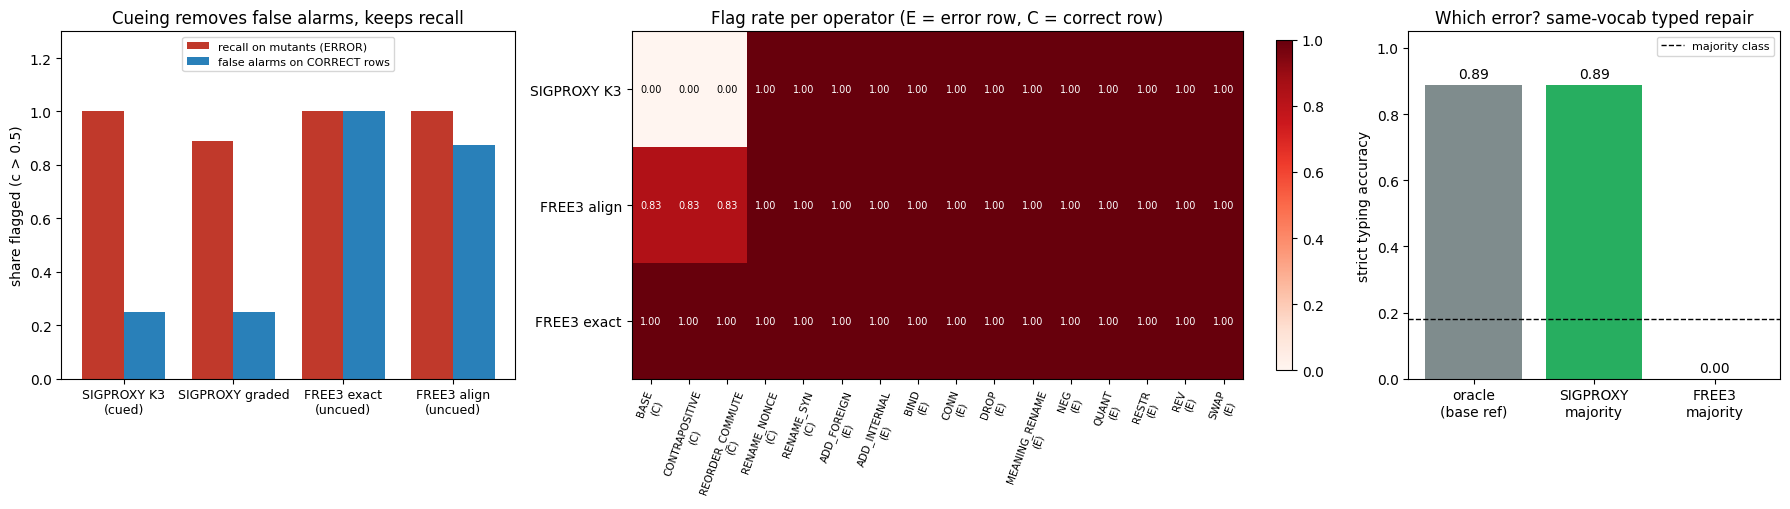

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), gridspec_kw={"width_ratios": [1.1, 1.6, 0.9]})

ax = axes[0]
arms = ["SIGPROXY K3 (cued)", "SIGPROXY graded", "FREE3 exact (uncued)", "FREE3 align (uncued)"]
x = np.arange(len(arms)); w = 0.38
ax.bar(x - w / 2, summ.loc[arms, "recall (ERROR flagged)"], w, label="recall on mutants (ERROR)", color="#c0392b")
ax.bar(x + w / 2, summ.loc[arms, "FA d (all CORRECT)"], w, label="false alarms on CORRECT rows", color="#2980b9")
ax.set_xticks(x); ax.set_xticklabels([a.replace(" (", "\n(") for a in arms], fontsize=9)
ax.set_ylim(0, 1.3); ax.set_ylabel("share flagged (c > 0.5)"); ax.legend(fontsize=8, loc="upper center", ncol=1)
ax.set_title("Cueing removes false alarms, keeps recall")

ax = axes[1]
order = per_op.sort_values(["label", "c_proxy"]).index
cols = ["c_proxy", "c_free3_align", "c_free3_exact"]
im = ax.imshow(per_op.loc[order, cols].T.values.astype(float), aspect="auto", cmap="Reds", vmin=0, vmax=1)
ax.set_xticks(range(len(order))); ax.set_xticklabels([f"{o}\n({per_op.loc[o, 'label'][0]})" for o in order], rotation=70, fontsize=7.5)
ax.set_yticks(range(3)); ax.set_yticklabels(["SIGPROXY K3", "FREE3 align", "FREE3 exact"])
for i, c in enumerate(cols):
    for j, o in enumerate(order):
        v = per_op.loc[o, c]
        if pd.notna(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7, color="white" if v > 0.6 else "black")
ax.set_title("Flag rate per operator (E = error row, C = correct row)")
fig.colorbar(im, ax=ax, fraction=0.025)

ax = axes[2]
ax.bar(["oracle\n(base ref)", "SIGPROXY\nmajority", "FREE3\nmajority"], ty["strict typing acc"], color=["#7f8c8d", "#27ae60", "#e67e22"])
ax.axhline(typing_df["true"].value_counts(normalize=True).iloc[0], ls="--", c="k", lw=1, label="majority class")
for i, v in enumerate(ty["strict typing acc"]):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
ax.set_ylim(0, 1.05); ax.set_ylabel("strict typing accuracy"); ax.legend(fontsize=8)
ax.set_title("Which error? same-vocab typed repair")
plt.tight_layout(); plt.show()